## Decision Tree

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [79]:
df = pd.read_csv("data/algerian_forest_fires_proj4.csv")
df.head()

,region,temp_c,rel_humidity_percent,wind_speed_kmh,rainfall_mm,ffmc,dmc,dc,isi,bui,fwi,classes
0,Bejaia,29.0,57.0,18.0,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,Bejaia,29.0,61.0,13.0,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire
2,Bejaia,26.0,82.0,22.0,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,Bejaia,25.0,89.0,13.0,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire
4,Bejaia,27.0,77.0,16.0,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire


In [80]:
df.shape

(243, 12)

### Creating the Decision Tree

In [81]:
tested_df = df.drop('region', axis=1).copy()
tested_df.head()

,temp_c,rel_humidity_percent,wind_speed_kmh,rainfall_mm,ffmc,dmc,dc,isi,bui,fwi,classes
0,29.0,57.0,18.0,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,29.0,61.0,13.0,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire
2,26.0,82.0,22.0,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,25.0,89.0,13.0,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire
4,27.0,77.0,16.0,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire


In [82]:
fire_data_x = tested_df.drop('classes', axis=1)
fire_data_y = tested_df['classes']

In [83]:
cross_validation = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [84]:
# Creating best Decision Tree using GridSearchCV
DEPTHS = [1, 5, 10, 20]
CRITERION = ['gini', 'entropy']
MAX_FEAT = ['sqrt', 'log2']

base_dt = DecisionTreeClassifier()

parameters = {
    'max_depth': DEPTHS,
    'criterion': CRITERION,
    'max_features': MAX_FEAT,
}

rf_grid = GridSearchCV(
    estimator=base_dt,
    param_grid=parameters,
    scoring='accuracy',
    cv=cross_validation,
    n_jobs=-1,
    verbose=2
)
rf_grid.fit(fire_data_x, fire_data_y)
print("Best parameters found: ", rf_grid.best_params_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END .....criterion=gini, max_depth=1, max_features=sqrt; total time=   0.0s
[CV] END .....criterion=gini, max_depth=1, max_features=sqrt; total time=   0.0s
[CV] END .....criterion=gini, max_depth=1, max_features=log2; total time=   0.0s
[CV] END .....criterion=gini, max_depth=1, max_features=log2; total time=   0.0s
[CV] END .....criterion=gini, max_depth=5, max_features=sqrt; total time=   0.0s
[CV] END .....criterion=gini, max_depth=5, max_features=sqrt; total time=   0.0s
[CV] END .....criterion=gini, max_depth=5, max_features=sqrt; total time=   0.0s
[CV] END .....criterion=gini, max_depth=5, max_features=sqrt; total time=   0.0s
[CV] END .....criterion=gini, max_depth=5, max_features=sqrt; total time=   0.0s
[CV] END .....criterion=gini, max_depth=5, max_features=log2; total time=   0.0s
[CV] END .....criterion=gini, max_depth=5, max_features=log2; total time=   0.0s
[CV] END .....criterion=gini, max_depth=5, max_f

In [85]:
BEST_DT_CLF = rf_grid.best_estimator_

In [86]:
final_scores = cross_val_score(
    BEST_DT_CLF,
    fire_data_x,
    fire_data_y,
    cv=cross_validation,
    scoring='accuracy',
)
print(final_scores.mean())

0.9753401360544217


In [87]:
fire_predict_y = cross_val_predict(BEST_DT_CLF, fire_data_x, fire_data_y, cv=cross_validation)

In [88]:
classification_accuracy = round(accuracy_score(fire_data_y, fire_predict_y) * 100, 4)
confusion_matrix = confusion_matrix(fire_data_y, fire_predict_y)
per_class_classification = classification_report(fire_data_y, fire_predict_y)

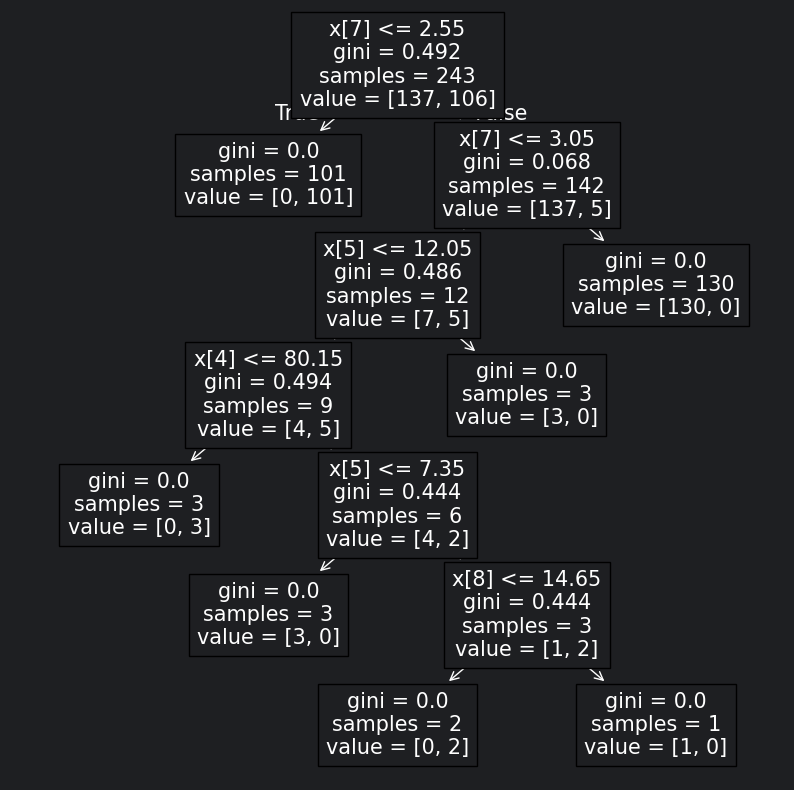

In [89]:
plt.figure(figsize=(10, 10))
tree.plot_tree(BEST_DT_CLF)
plt.show()

In [93]:
print(per_class_classification)

              precision    recall  f1-score   support

        fire       0.97      0.97      0.97       137
    not fire       0.96      0.96      0.96       106

    accuracy                           0.97       243
   macro avg       0.97      0.97      0.97       243
weighted avg       0.97      0.97      0.97       243

